## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ajuste ROOT se necessário — aponta para a raiz do repositório
ROOT      = Path("C:/Users/Pedro/Projects/OSPA Place Case")
RAW       = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

assert ROOT.exists(), f"Raiz não encontrada: {ROOT}"
assert PROCESSED.exists(), f"Pasta processed não encontrada — rode o ETL primeiro"

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4)})
print("✅ Paths configurados")
print(f"   RAW       → {RAW}")
print(f"   PROCESSED → {PROCESSED}")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

✅ Paths configurados
   RAW       → C:\Users\Pedro\Projects\OSPA Place Case\data\raw
   PROCESSED → C:\Users\Pedro\Projects\OSPA Place Case\data\processed


In [2]:
def load_raw(
    subdir: str,
    filename: str,
    sep: str = ",",
    nrows: int | None = None
) -> pd.DataFrame:
    """
    Carrega CSV raw com detecção automática de encoding.

    :param subdir: Subpasta dentro de data/raw
    :param filename: Nome do arquivo CSV
    :param sep: Separador do CSV
    :param nrows: Limite de linhas (None = tudo)
    :return: DataFrame carregado
    """
    path = RAW / subdir / filename
    for enc in ("utf-8", "latin-1", "cp1252", "ISO-8859-1"):
        try:
            return pd.read_csv(path, dtype=str, encoding=enc,
                               sep=sep, low_memory=False, nrows=nrows)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível ler {path} com nenhum encoding testado")


def profile(
    df: pd.DataFrame,
    label: str
) -> None:
    """
    Exibe perfil básico de um DataFrame: shape, dtypes e % de nulos.

    :param df: DataFrame a analisar
    :param label: Rótulo para identificação
    """
    nulos = (df.isnull().mean() * 100).round(1).rename("nulos_%")
    resumo = pd.concat([df.dtypes.rename("dtype"), nulos], axis=1)
    print(f"\n{'='*55}")
    print(f"  {label}  —  shape: {df.shape}")
    print(f"{'='*55}")
    print(resumo.to_string())


def bar_top(
    series: pd.Series,
    title: str,
    n: int = 15,
    color: str = "#4C72B0"
) -> None:
    """
    Plota barras horizontais com os top-N valores de uma Series.

    :param series: Series com contagens ou valores
    :param title: Título do gráfico
    :param n: Número de barras
    :param color: Cor das barras
    """
    ax = series.head(n).sort_values().plot(
        kind="barh", title=title, color=color, edgecolor="white"
    )
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()


print("✅ Helpers definidos")

✅ Helpers definidos


---
## 1. RAW — Atividade Econômica

In [3]:
df_eco_raw = load_raw(
    "atividade_economica",
    "atividade_economica.csv",
    sep=";"
)
profile(df_eco_raw, "Atividade Econômica RAW")
df_eco_raw.head(3)


  Atividade Econômica RAW  —  shape: (564344, 22)
                               dtype  nulos_%
ID_ATIV_ECON_ESTABELECIMENTO  object      0.0
CNAE_PRINCIPAL                object      0.0
DESCRICAO_CNAE_PRINCIPAL      object      0.0
CNAE                          object      0.0
DATA_INICIO_ATIVIDADE         object      0.0
NATUREZA_JURIDICA             object      0.0
PORTE_EMPRESA                 object      0.0
AREA_UTILIZADA                object      0.0
IND_SIMPLES                   object      0.0
IND_MEI                       object      0.0
IND_POSSUI_ALVARA             object      0.0
TIPO_UNIDADE                  object      0.0
FORMA_ATUACAO                 object     12.4
DESC_LOGRADOURO               object      0.0
NOME_LOGRADOURO               object      0.0
NUMERO_IMOVEL                 object      0.0
COMPLEMENTO                   object     46.8
NOME_BAIRRO                   object      0.0
NOME                          object      0.0
NOME_FANTASIA                

,ID_ATIV_ECON_ESTABELECIMENTO,CNAE_PRINCIPAL,DESCRICAO_CNAE_PRINCIPAL,CNAE,DATA_INICIO_ATIVIDADE,NATUREZA_JURIDICA,PORTE_EMPRESA,AREA_UTILIZADA,IND_SIMPLES,IND_MEI,IND_POSSUI_ALVARA,TIPO_UNIDADE,FORMA_ATUACAO,DESC_LOGRADOURO,NOME_LOGRADOURO,NUMERO_IMOVEL,COMPLEMENTO,NOME_BAIRRO,NOME,NOME_FANTASIA,CNPJ,GEOMETRIA
0,658,4110700,INCORPORACAO DE EMPREENDIMENTOS IMOBILIARIOS,"4110700, 4120400, 4399101",04-05-1992,SOCIEDADE EMPRESÁRIA LIMITADA,EMPRESA DE PEQUENO PORTE,28,N,N,NÃO,ESCRITÓRIO ADMINSTRATIVO,NaN,RUA,JACUI,505,"SALA: 01,",COLEGIO BATISTA,CONSTRUTORA A R B LTDA,NaN,41911819000198,POINT (611748.06 7798276.46)
1,659,8030700,ATIVIDADES DE INVESTIGACAO PARTICULAR,"8030700, 8291100",01-09-1993,SOCIEDADE SIMPLES LIMITADA,MICROEMPRESA - ME,63,S,N,SIM,ESCRITÓRIO ADMINSTRATIVO,NaN,AVE,DO CONTORNO,4640,SALA 701 SALA 702,FUNCIONARIOS,A A ABA AGENCIA DE PESQUISA LTDA,LIDER INVESTIGACOES SIGILOSAS,73487613000179,POINT (612479.69 7795347.82)
2,660,6920601,ATIVIDADES DE CONTABILIDADE,6920601,12-11-1993,SOCIEDADE SIMPLES LIMITADA,EMPRESA DE PEQUENO PORTE,60,S,N,SIM,UNIDADE PRODUTIVA,ESTABELECIMENTO FIXO,RUA,DOS GUAJAJARAS,910,"SALA: 16191620 ,",CENTRO,METROPOLE INTEGRACAO CONTABIL LTDA,METROPOLE CONTABIL,73788218000126,POINT (610658.10 7796519.70)


In [4]:
# Distribuição de situação das empresas
if "SITUACAO" in df_eco_raw.columns:
    bar_top(df_eco_raw["SITUACAO"].value_counts(), "Situação das Empresas (RAW)")
else:
    print("Coluna SITUACAO não encontrada. Colunas disponíveis:", df_eco_raw.columns.tolist())

Coluna SITUACAO não encontrada. Colunas disponíveis: ['ID_ATIV_ECON_ESTABELECIMENTO', 'CNAE_PRINCIPAL', 'DESCRICAO_CNAE_PRINCIPAL', 'CNAE', 'DATA_INICIO_ATIVIDADE', 'NATUREZA_JURIDICA', 'PORTE_EMPRESA', 'AREA_UTILIZADA', 'IND_SIMPLES', 'IND_MEI', 'IND_POSSUI_ALVARA', 'TIPO_UNIDADE', 'FORMA_ATUACAO', 'DESC_LOGRADOURO', 'NOME_LOGRADOURO', 'NUMERO_IMOVEL', 'COMPLEMENTO', 'NOME_BAIRRO', 'NOME', 'NOME_FANTASIA', 'CNPJ', 'GEOMETRIA']


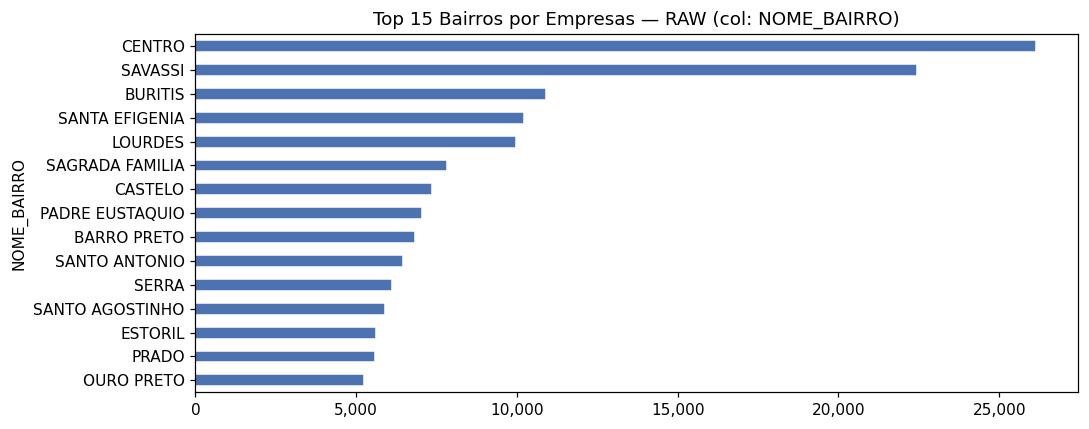

In [5]:
# Top bairros por número de registros
col_bairro_eco = next((c for c in df_eco_raw.columns if "BAIRRO" in c.upper()), None)
if col_bairro_eco:
    bar_top(
        df_eco_raw[col_bairro_eco].value_counts(),
        f"Top 15 Bairros por Empresas — RAW (col: {col_bairro_eco})"
    )
else:
    print("Coluna de bairro não encontrada. Colunas:", df_eco_raw.columns.tolist())

## 2. PROCESSED — Empresas por Bairro

In [6]:
df_eco = pd.read_parquet(PROCESSED / "empresas_por_bairro.parquet", engine="pyarrow")
profile(df_eco, "empresas_por_bairro PROCESSED")
df_eco.head()


  empresas_por_bairro PROCESSED  —  shape: (489, 4)
                      dtype  nulos_%
bairro               object      0.0
total_empresas        int64      0.0
diversidade_setores   int64      0.0
setor_dominante      object      0.0


,bairro,total_empresas,diversidade_setores,setor_dominante
0,CENTRO,26143,81,47
1,SAVASSI,22439,79,86
2,BURITIS,10897,68,81
3,SANTA EFIGENIA,10205,75,86
4,LOURDES,9957,77,86


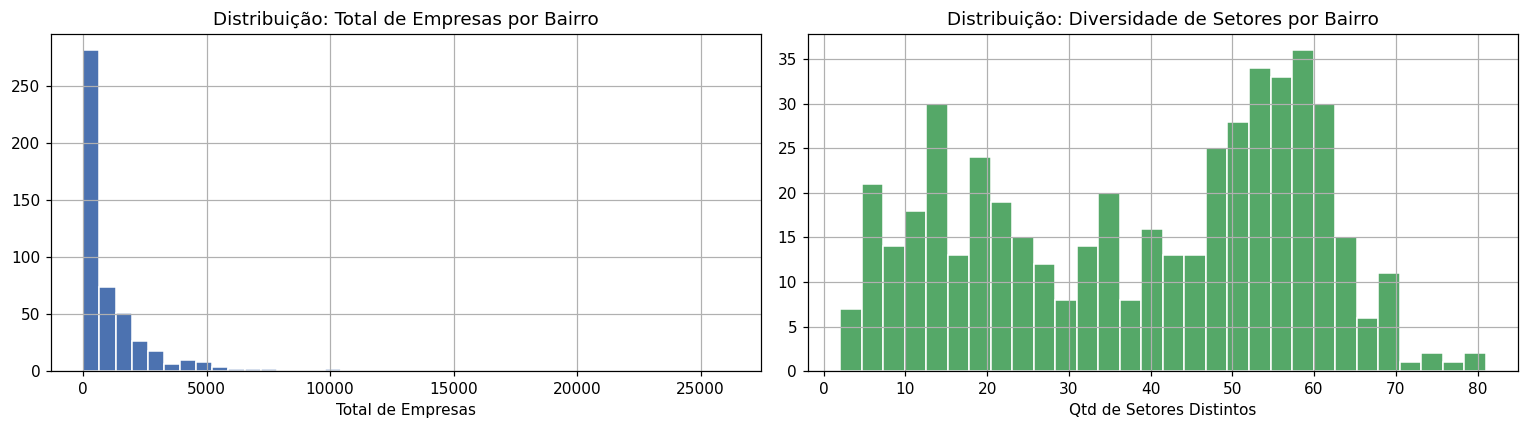

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eco["total_empresas"].hist(bins=40, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Total de Empresas por Bairro")
axes[0].set_xlabel("Total de Empresas")

df_eco["diversidade_setores"].hist(bins=30, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Diversidade de Setores por Bairro")
axes[1].set_xlabel("Qtd de Setores Distintos")

plt.tight_layout()
plt.show()

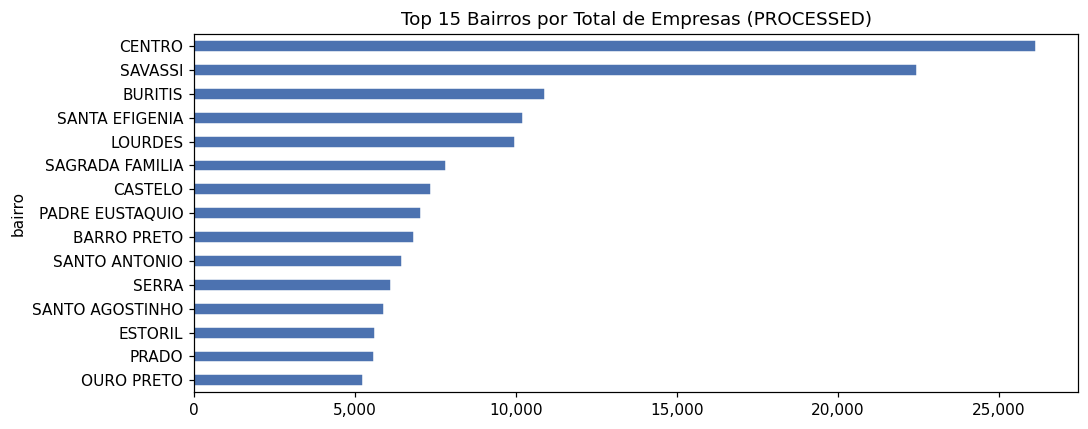

In [9]:
# Top 15 bairros por empresas (PROCESSED)
bar_top(
    df_eco.set_index("bairro")["total_empresas"],
    "Top 15 Bairros por Total de Empresas (PROCESSED)"
)

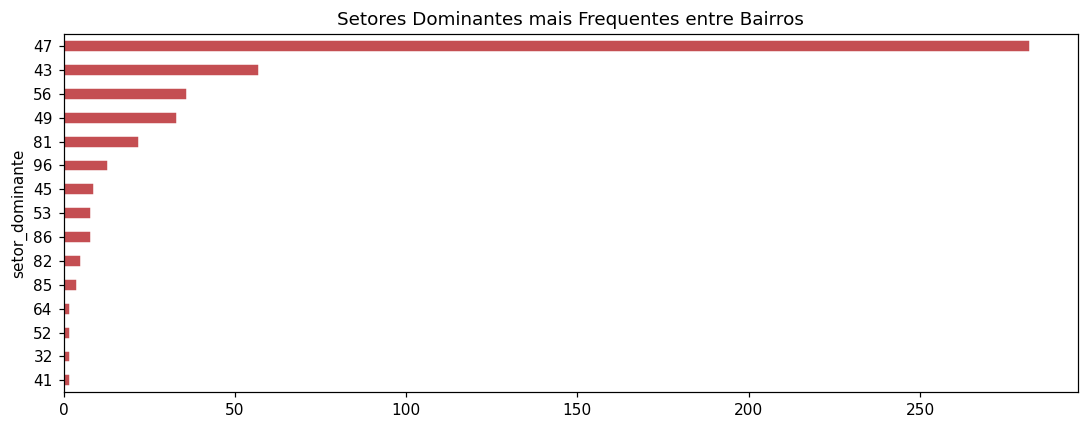

In [10]:
# Setor dominante mais frequente
bar_top(
    df_eco["setor_dominante"].value_counts(),
    "Setores Dominantes mais Frequentes entre Bairros",
    color="#C44E52"
)

---
## 3. RAW — Pontos de Ônibus

In [12]:
df_pts_raw = load_raw("pontos_onibus", "pontos_onibus.csv", sep=";")
profile(df_pts_raw, "Pontos de Ônibus RAW")
df_pts_raw.head(3)


  Pontos de Ônibus RAW  —  shape: (69133, 7)
                             dtype  nulos_%
ID_PONTO_ONIBUS_LINHA       object      0.0
COD_LINHA                   object      0.0
NOME_LINHA                  object      0.0
NOME_SUB_LINHA              object      0.0
ORIGEM                      object      0.0
IDENTIFICADOR_PONTO_ONIBUS  object      0.0
GEOMETRIA                   object      0.0


,ID_PONTO_ONIBUS_LINHA,COD_LINHA,NOME_LINHA,NOME_SUB_LINHA,ORIGEM,IDENTIFICADOR_PONTO_ONIBUS,GEOMETRIA
0,6798,301,EST.DIAMANTE-NOVO STA.CECILIA V. BRASIL INDUST...,VIA RUA DA OLARIA,ESTACAO DIAMANTE,6798,POINT (603081.68 7788956.99)
1,6799,301,EST.DIAMANTE-NOVO STA.CECILIA V. BRASIL INDUST...,VIA RUA DA OLARIA,ESTACAO DIAMANTE,6799,POINT (602963.12 7788876.8)
2,6800,301,EST.DIAMANTE-NOVO STA.CECILIA V. BRASIL INDUST...,VIA RUA DA OLARIA,ESTACAO DIAMANTE,6800,POINT (602944.08 7788493.81)


In [13]:
# Verifica se tem coluna de bairro ou só geometria
col_bairro_pts = next((c for c in df_pts_raw.columns if "BAIRRO" in c.upper()), None)
if col_bairro_pts:
    bar_top(
        df_pts_raw[col_bairro_pts].value_counts(),
        f"Top 15 Bairros por Pontos de Ônibus — RAW (col: {col_bairro_pts})"
    )
else:
    print("Dataset não tem coluna de bairro — usa spatial join no ETL (esperado).")
    print("Colunas disponíveis:", df_pts_raw.columns.tolist())

Dataset não tem coluna de bairro — usa spatial join no ETL (esperado).
Colunas disponíveis: ['ID_PONTO_ONIBUS_LINHA', 'COD_LINHA', 'NOME_LINHA', 'NOME_SUB_LINHA', 'ORIGEM', 'IDENTIFICADOR_PONTO_ONIBUS', 'GEOMETRIA']


## 4. PROCESSED — Acessibilidade por Bairro

In [19]:
df_acid_raw = load_raw("acidentes_transito", "acidentes_transito.csv", sep=";")
profile(df_acid_raw, "Acidentes de Trânsito RAW")
df_acid_raw.head(3)


  Acidentes de Trânsito RAW  —  shape: (13266, 23)
                       dtype  nulos_%
NUMERO_BOLETIM        object      0.0
DATA HORA_BOLETIM     object      0.0
DATA_INCLUSAO         object      0.0
TIPO_ACIDENTE         object      0.0
DESC_TIPO_ACIDENTE    object      0.0
COD_TEMPO             object      0.0
DESC_TEMPO            object      0.0
COD_PAVIMENTO         object      0.0
PAVIMENTO             object      0.0
COD_REGIONAL          object      0.0
DESC_REGIONAL         object      0.0
ORIGEM_BOLETIM        object      0.0
LOCAL_SINALIZADO      object      0.0
VELOCIDADE_PERMITIDA  object      0.0
COORDENADA_X          object      0.0
COORDENADA_Y          object      0.0
HORA_INFORMADA        object      0.0
INDICADOR_FATALIDADE  object      0.0
VALOR_UPS             object      0.0
DESCRIÇÃO_UPS         object      0.0
DATA_ALTERACAO_SMSA   object      0.0
VALOR_UPS_ANTIGA      object      0.0
DESCRIÇÃO_UPS_ANTIGA  object      0.0


,NUMERO_BOLETIM,DATA HORA_BOLETIM,DATA_INCLUSAO,TIPO_ACIDENTE,DESC_TIPO_ACIDENTE,COD_TEMPO,DESC_TEMPO,COD_PAVIMENTO,PAVIMENTO,COD_REGIONAL,DESC_REGIONAL,ORIGEM_BOLETIM,LOCAL_SINALIZADO,VELOCIDADE_PERMITIDA,COORDENADA_X,COORDENADA_Y,HORA_INFORMADA,INDICADOR_FATALIDADE,VALOR_UPS,DESCRIÇÃO_UPS,DATA_ALTERACAO_SMSA,VALOR_UPS_ANTIGA,DESCRIÇÃO_UPS_ANTIGA
0,2024-048009883-001,25/10/2024 13:01,25/10/2024 13:18,H09002,COLISAO DE VEICULOS COM VITIMA ...,4,NUBLADO,1,ASFALTO,20,LESTE,POLICIA MILITAR,NÃO,0,0000614200.25,0007797930.35,SIM,NÃO,0,NÃO INFORMADO,00/00/0000,0,NÃO INFORMADO
1,2024-048011159-001,25/10/2024 09:35,25/10/2024 13:29,H01002,ABALROAMENTO COM VITIMA ...,1,BOM,1,ASFALTO,19,CENTRO-SUL,POLICIA MILITAR,NÃO,0,0000609848.07,0007793140.24,SIM,NÃO,0,NÃO INFORMADO,00/00/0000,0,NÃO INFORMADO
2,2024-048014306-001,25/10/2024 12:55,25/10/2024 13:52,H06002,ATROPELAMENTO DE PESSOA SEM VITIMA FATAL ...,0,NAO INFORMADO,0,NAO INFORMADO,25,PAMPULHA,POLICIA MILITAR,NÃO,0,0000605621.44,0007799291.44,SIM,NÃO,0,NÃO INFORMADO,00/00/0000,0,NÃO INFORMADO


In [21]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

CRS_UTM   = "EPSG:31983"
CRS_WGS84 = "EPSG:4326"

In [40]:
# ── 1. Carrega acidentes e converte coordenadas ───────────────────────────────
df_acid_raw = load_raw("acidentes_transito", "acidentes_transito.csv", sep=";")

# Remover o espaço extra no nome das colunas
df_acid_raw.columns = df_acid_raw.columns.str.strip()

# Coordenadas chegam como string com vírgula decimal — troca por ponto
df_acid = df_acid_raw[["NUMERO_BOLETIM", "COORDENADA_X", "COORDENADA_Y"]].copy()
df_acid["x"] = pd.to_numeric(df_acid["COORDENADA_X"].str.replace(",", "."), errors="coerce")
df_acid["y"] = pd.to_numeric(df_acid["COORDENADA_Y"].str.replace(",", "."), errors="coerce")

total = len(df_acid)
sem_coords = df_acid[["x", "y"]].isna().any(axis=1).sum()
print(f"Total de acidentes: {total:,}")
print(f"Sem coordenadas válidas: {sem_coords:,} ({sem_coords/total*100:.1f}%)")

df_acid = df_acid.dropna(subset=["x", "y"])

Total de acidentes: 13,266
Sem coordenadas válidas: 0 (0.0%)


In [41]:
# ── 2. Cria GeoDataFrame de pontos ───────────────────────────────────────────
gdf_acid = gpd.GeoDataFrame(
    df_acid,
    geometry=gpd.points_from_xy(df_acid["x"], df_acid["y"]),
    crs=CRS_UTM,
)
print(f"\nAcidentes com coordenadas: {len(gdf_acid):,}")
print(f"CRS dos acidentes: {gdf_acid.crs}")


Acidentes com coordenadas: 13,266
CRS dos acidentes: EPSG:31983


In [42]:
# ── 3. Carrega polígonos de bairros ──────────────────────────────────────────
from shapely import wkt

df_bairros_raw = load_raw("bairros", "bairros.csv", sep=",")
df_bairros_raw.columns = df_bairros_raw.columns.str.strip().str.upper()

# Detecta coluna de nome e geometria
col_nome = next(c for c in df_bairros_raw.columns if c in ("NOME", "NOME_BAIRRO"))
col_geom = next(c for c in df_bairros_raw.columns if "GEOM" in c)

df_bairros_raw = df_bairros_raw.dropna(subset=[col_geom])
df_bairros_raw["geometry"] = df_bairros_raw[col_geom].map(
    lambda w: wkt.loads(w) if isinstance(w, str) else None
)
df_bairros_raw = df_bairros_raw.dropna(subset=["geometry"])

gdf_bairros = gpd.GeoDataFrame(
    df_bairros_raw[[col_nome, "geometry"]].rename(columns={col_nome: "bairro"}),
    crs=CRS_UTM,
)
print(f"\nPolígonos de bairros carregados: {len(gdf_bairros)}")


Polígonos de bairros carregados: 322


In [43]:
# ── 4. Spatial join: ponto dentro do polígono ────────────────────────────────
gdf_joined = gpd.sjoin(
    gdf_acid[["NUMERO_BOLETIM", "geometry"]],
    gdf_bairros[["bairro", "geometry"]],
    how="left",
    predicate="within",
)

sem_bairro = gdf_joined["bairro"].isna().sum()
print(f"\nAcidentes sem bairro após spatial join: {sem_bairro:,} ({sem_bairro/len(gdf_joined)*100:.1f}%)")


Acidentes sem bairro após spatial join: 771 (5.8%)


In [44]:
# ── 5. Agrega por bairro ─────────────────────────────────────────────────────
acidentes_por_bairro = (
    gdf_joined
    .groupby("bairro", as_index=False)
    .size()
    .rename(columns={"size": "total_acidentes_sjoin"})
    .sort_values("total_acidentes_sjoin", ascending=False)
)

print(f"\nBairros com pelo menos 1 acidente: {len(acidentes_por_bairro)}")
print("\nTop 15 bairros por acidentes (spatial join):")
print(acidentes_por_bairro.head(15).to_string(index=False))


Bairros com pelo menos 1 acidente: 276

Top 15 bairros por acidentes (spatial join):
         bairro  total_acidentes_sjoin
          Sexta                    445
Celeste Império                    325
  Carlos Prates                    305
        Segunda                    283
       Primeira                    236
       Terceira                    234
         Oitava                    226
       do Pilar                    203
      Dom Bosco                    200
       São Luíz                    185
        Estoril                    160
         Jatobá                    160
      São Pedro                    136
          União                    135
           Tupi                    129


In [45]:
# ── 6. Compara com o valor atual no processed ────────────────────────────────
print("\n--- Comparação com PROCESSED atual ---")
print("Valores únicos de total_acidentes no processed:")
print(df_ace["total_acidentes"].value_counts().head(5))
print("\n→ Se todos os valores forem iguais, confirma o bug.")
print("→ Se variarem, o ETL já foi corrigido.")


--- Comparação com PROCESSED atual ---
Valores únicos de total_acidentes no processed:
total_acidentes
13266    286
Name: count, dtype: int64

→ Se todos os valores forem iguais, confirma o bug.
→ Se variarem, o ETL já foi corrigido.


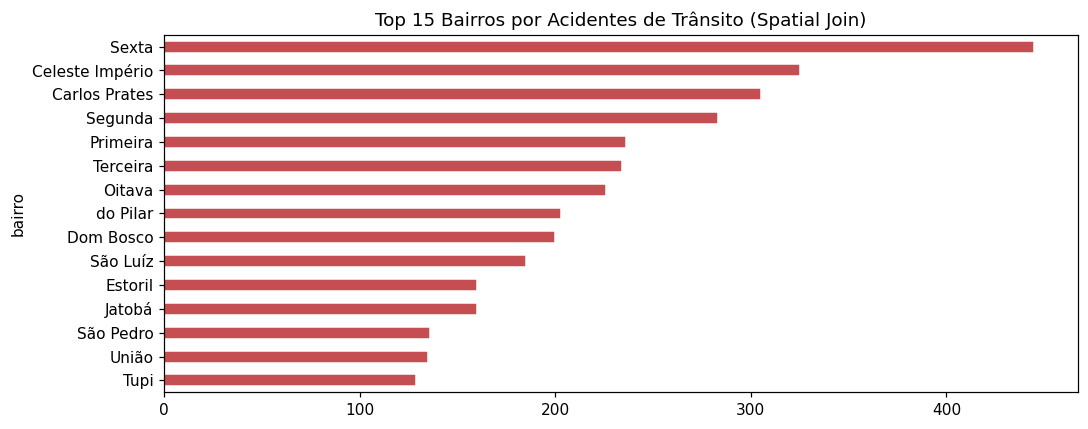

In [46]:
# ── 7. Visualização da distribuição nova ─────────────────────────────────────
bar_top(
    acidentes_por_bairro.set_index("bairro")["total_acidentes_sjoin"],
    "Top 15 Bairros por Acidentes de Trânsito (Spatial Join)",
    color="#C44E52"
)

In [14]:
df_ace = pd.read_parquet(PROCESSED / "acessibilidade_por_bairro.parquet")
profile(df_ace, "acessibilidade_por_bairro PROCESSED")
df_ace.head()


  acessibilidade_por_bairro PROCESSED  —  shape: (286, 5)
                         dtype  nulos_%
bairro                  object      0.0
total_pontos_onibus      int64      0.0
total_embarques_dia    float64      0.0
total_acidentes          int64      0.0
indice_acessibilidade  float64      0.0


,bairro,total_pontos_onibus,total_embarques_dia,total_acidentes,indice_acessibilidade
0,AARAO REIS,440,37.0,13266,0.5437
1,ADALBERTO FERRAZ,228,4663.0,13266,0.8028
2,ADELAIDE,101,344.0,13266,0.4538
3,ADELIA,178,1250.0,13266,0.6063
4,ADELINA,48,169.0,13266,0.3448


In [18]:
df_ace["total_acidentes"].value_counts().head(10)

total_acidentes
13266    286
Name: count, dtype: int64

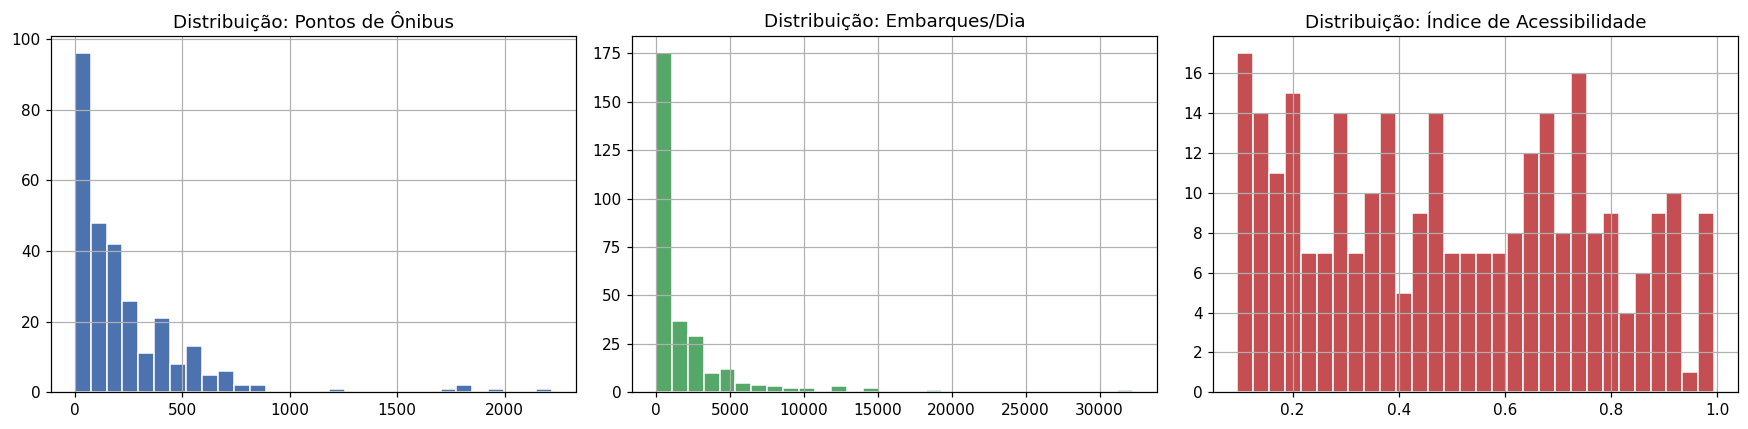

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_ace["total_pontos_onibus"].hist(bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Pontos de Ônibus")

df_ace["total_embarques_dia"].hist(bins=30, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Embarques/Dia")

df_ace["indice_acessibilidade"].hist(bins=30, ax=axes[2], color="#C44E52", edgecolor="white")
axes[2].set_title("Distribuição: Índice de Acessibilidade")

plt.tight_layout()
plt.show()

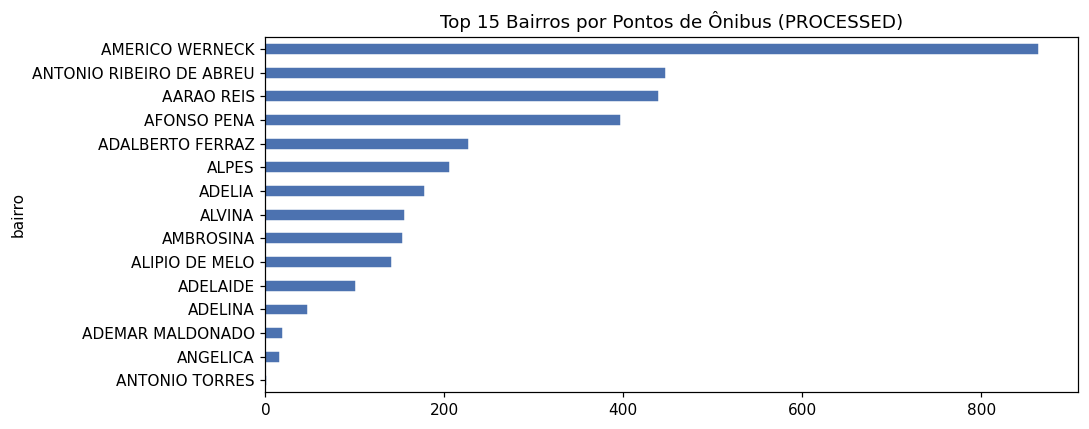

In [16]:
# Top 15 bairros por pontos de ônibus
bar_top(
    df_ace.set_index("bairro")["total_pontos_onibus"],
    "Top 15 Bairros por Pontos de Ônibus (PROCESSED)"
)

In [48]:
%%capture
pip install rapidfuzz

In [52]:
from rapidfuzz import fuzz, process

# Carrega usando o RAW já definido no setup do notebook
eco = pd.read_csv(
    RAW / "atividade_economica" / "atividade_economica.csv",
    sep=";", dtype=str, encoding="utf-8"
)
eco.columns = eco.columns.str.strip().str.upper()

canonicos = (
    eco["NOME_BAIRRO"].str.strip().str.upper()
    .str.normalize("NFD").str.encode("ascii", errors="ignore").str.decode("ascii")
    .dropna().unique().tolist()
)

# Bairros que aparecem no CSV de exclusões como score_baixo
# mas que parecem ser nomes populares legítimos
suspeitos = [
    "ADALBERTO FERRAZ", "CELESTE IMPERIO", "NOVA YORK", "NOVA SUICA",
    "PAMPULHA", "JOAO PESSOA", "SANTOS DUMONT", "NOVA HORIZONTE",
    "SAO DOMINGOS", "SAO LEOPOLDO", "RIACHUELO", "PATROCINIO",
]

print(f"{'Nome suspeito':<30} {'Melhor match':<30} {'Score':>6}")
print("-" * 70)
for nome in suspeitos:
    resultado = process.extractOne(nome, canonicos, scorer=fuzz.WRatio)
    if resultado:
        print(f"{nome:<30} {resultado[0]:<30} {resultado[1]:>6.1f}")
    else:
        print(f"{nome:<30} {'(nenhum)':<30} {'—':>6}")

Nome suspeito                  Melhor match                    Score
----------------------------------------------------------------------
ADALBERTO FERRAZ               SERRA                            72.0
CELESTE IMPERIO                OESTE                            72.0
NOVA YORK                      NOVA GAMELEIRA                   85.5
NOVA SUICA                     NOVA SUISSA                      85.7
PAMPULHA                       NOVA PAMPULHA                    90.0
JOAO PESSOA                    VILA SAO JOAO BATISTA            85.5
SANTOS DUMONT                  SANTA MONICA                     64.0
NOVA HORIZONTE                 VILA NOVA GAMELEIRA I            85.5
SAO DOMINGOS                   SAO JOSE                         85.5
SAO LEOPOLDO                   SAO JOSE                         85.5
RIACHUELO                      GLORIA                           60.0
PATROCINIO                     UNIAO                            67.5


In [51]:
import pandas as pd
from rapidfuzz import fuzz, process

eco = pd.read_csv("data/raw/atividade_economica/atividade_economica.csv",
                  sep=";", dtype=str, encoding="utf-8")
eco.columns = eco.columns.str.strip().str.upper()
canonicos = (
    eco["NOME_BAIRRO"].str.strip().str.upper()
    .str.normalize("NFD").str.encode("ascii", errors="ignore").str.decode("ascii")
    .dropna().unique().tolist()
)

# Testa os suspeitos
suspeitos = ["ADALBERTO FERRAZ", "CELESTE IMPERIO", "NOVA YORK", "NOVA SUICA",
             "PAMPULHA", "JOAO PESSOA"]

for nome in suspeitos:
    resultado = process.extractOne(nome, canonicos, scorer=fuzz.WRatio)
    print(f"{nome:30} -> {resultado}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/atividade_economica/atividade_economica.csv'

---
## 5. RAW — Qualidade Urbana (Parques e Equipamentos)

In [ ]:
df_parq_raw   = load_raw("parques", "parques.csv")
df_equip_raw  = load_raw("equipamentos_esportivos", "equipamentos_esportivos.csv")
profile(df_parq_raw, "Parques RAW")
profile(df_equip_raw, "Equipamentos Esportivos RAW")

## 6. PROCESSED — Qualidade Urbana por Bairro

In [ ]:
df_qua = pd.read_parquet(PROCESSED / "qualidade_urbana_por_bairro.parquet")
profile(df_qua, "qualidade_urbana_por_bairro PROCESSED")
df_qua.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_qua["total_parques"].hist(bins=20, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Parques por Bairro")

df_qua["total_equipamentos_esportivos"].hist(bins=20, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Equipamentos Esportivos por Bairro")

plt.tight_layout()
plt.show()

---
## 7. RAW — Matriz O-D

In [ ]:
# Carrega só 5k linhas para não travar — dataset tem 188k registros
df_od_raw = load_raw("matriz_od", "matriz_od.csv", sep=";", nrows=5000)
profile(df_od_raw, "Matriz O-D RAW (amostra 5k)")
df_od_raw.head(3)

In [ ]:
print(f"Origens H3 únicas (amostra): {df_od_raw['H3_ORIGEM'].nunique()}")
print(f"Destinos H3 únicos (amostra): {df_od_raw['H3_DESTINO'].nunique()}")

if "TIPO_CARTAO" in df_od_raw.columns:
    bar_top(
        df_od_raw["TIPO_CARTAO"].value_counts(),
        "Distribuição por Tipo de Cartão — Matriz O-D (amostra)",
        color="#8172B2"
    )

## 8. PROCESSED — Matriz O-D Agregada

In [ ]:
df_od = pd.read_parquet(PROCESSED / "matriz_od_agregada.parquet")
profile(df_od, "matriz_od_agregada PROCESSED")
df_od.head()

In [ ]:
if len(df_od) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df_od["total_viagens_originadas"].hist(bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
    axes[0].set_title("Distribuição: Viagens Originadas por Bairro")

    df_od["destinos_unicos"].hist(bins=30, ax=axes[1], color="#8172B2", edgecolor="white")
    axes[1].set_title("Distribuição: Destinos Únicos por Bairro")

    plt.tight_layout()
    plt.show()

    bar_top(
        df_od.set_index("bairro")["total_viagens_originadas"],
        "Top 15 Bairros por Viagens Originadas (PROCESSED)",
        color="#8172B2"
    )
else:
    print("⚠️ matriz_od_agregada.parquet está vazio — verifique o ETL da matriz O-D")

---
## 9. PROCESSED — Score Final

In [ ]:
df_score = pd.read_parquet(PROCESSED / "score_final.parquet")
profile(df_score, "score_final PROCESSED")
df_score[["ranking", "bairro", "score_final", "score_eco", "score_ace", "score_qua"]].head(15)

In [ ]:
# Distribuição do score final
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_score["score_final"].hist(bins=40, ax=axes[0], color="#DD8452", edgecolor="white")
axes[0].set_title("Distribuição do Score Final (0–100)")
axes[0].set_xlabel("Score")

df_score[["score_eco", "score_ace", "score_qua"]].plot(
    kind="hist", bins=30, alpha=0.6, ax=axes[1],
    color=["#4C72B0", "#55A868", "#C44E52"]
)
axes[1].set_title("Distribuição dos Scores por Dimensão")
axes[1].set_xlabel("Score da Dimensão")

plt.tight_layout()
plt.show()

In [ ]:
# Top 20 bairros
top20 = df_score.head(20).set_index("bairro")[["score_eco", "score_ace", "score_qua"]]

top20.plot(
    kind="barh", stacked=True, figsize=(12, 8),
    color=["#4C72B0", "#55A868", "#C44E52"],
    title="Top 20 Bairros — Composição do Score Final"
)
plt.xlabel("Score (componentes)")
plt.legend(["Econômico (40%)", "Acessibilidade (35%)", "Qualidade Urbana (25%)"])
plt.tight_layout()
plt.show()

In [ ]:
# Correlação entre dimensões
corr = df_score[["score_eco", "score_ace", "score_qua", "score_final"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Correlação entre Dimensões do Score")
plt.tight_layout()
plt.show()

---
## 10. Consistência de Bairros entre Fontes PROCESSED

In [ ]:
# Quantos bairros cada fonte tem e quais estão no score final
fontes = {
    "empresas":      set(df_eco["bairro"]),
    "acessibilidade": set(df_ace["bairro"]),
    "qualidade":     set(df_qua["bairro"]),
    "matriz_od":     set(df_od["bairro"]) if len(df_od) > 0 else set(),
    "score_final":   set(df_score["bairro"]),
}

print("Bairros por fonte:")
for nome, bairros in fontes.items():
    print(f"  {nome:<20} {len(bairros):>4} bairros")

# Bairros presentes em todas as fontes com dados
fontes_com_dados = {k: v for k, v in fontes.items() if v}
intersecao = set.intersection(*fontes_com_dados.values())
print(f"\nBairros em TODAS as fontes (interseção): {len(intersecao)}")

# Bairros só no score (sem dados em nenhuma fonte individual)
bairros_sem_fonte = fontes["score_final"] - fontes["empresas"] - fontes["acessibilidade"] - fontes["qualidade"]
print(f"Bairros no score sem dados em nenhuma fonte individual: {len(bairros_sem_fonte)}")
if bairros_sem_fonte:
    print("  Exemplos:", sorted(bairros_sem_fonte)[:10])

In [ ]:
# Bairros da acessibilidade que NÃO estão nas empresas — candidatos a problemas de join
so_ace = fontes["acessibilidade"] - fontes["empresas"]
so_eco = fontes["empresas"] - fontes["acessibilidade"]

print(f"Bairros só em acessibilidade (não em empresas): {len(so_ace)}")
print(f"Bairros só em empresas (não em acessibilidade): {len(so_eco)}")
print("\nExemplos bairros só em acessibilidade:", sorted(so_ace)[:8])
print("Exemplos bairros só em empresas:",       sorted(so_eco)[:8])